# Project Scope: Endangered Species Analysis in National Parks

## Goals
- Analyze the distribution of conservation statuses across species categories.
- Identify categories or parks with higher proportions of endangered species.
- Examine observation frequency to assess species prevalence in national parks.
- Uncover patterns or themes in endangerment.

## Data Sources
- **species_info.csv**: Contains species details:
  - Columns: category, scientific_name, common_names, conservation_status.
  - Purpose: Understand species characteristics and conservation status.
- **observations.csv**: Records sightings over the past 7 days:
  - Columns: scientific_name, park_name, observations.
  - Purpose: Quantify species presence across parks.

## Analytical Steps
1. **Load and Clean Data**:
   - Handle missing or inconsistent conservation statuses.
   - Remove duplicates and standardize formats.
2. **Exploratory Analysis**:
   - Summarize conservation statuses by category and park.
   - Calculate summary statistics (e.g., mean observations per species).
3. **Data Merging**:
   - Merge datasets on `scientific_name` to correlate status with observations.
4. **Visualization**:
   - Bar plots for conservation status distribution by category.
   - Box plots for observation counts by park or status.
5. **Pattern Analysis**:
   - Test associations.
   - Compare observation trends for endangered vs. non-endangered species.
6. **Conclusions and Presentation**:
   - Summarize key findings.
   - Create a slide deck to communicate results.

In [22]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load and Verify the Data

Load the two provided CSV files into pandas DataFrames and perform initial verification to ensure data quality:
- **species_info.csv**: Contains species details (category, scientific name, common names, conservation status).
- **observations.csv**: Records sightings of species across national parks over the past 7 days.

Using the `pandas` library to:
- Load the data and display summaries (head, info, describe) to understand the structure.
- Check for duplicate rows to ensure data uniqueness.
- Identify missing values to assess data completeness.
- Verify data alignment (e.g., consistent scientific names, correct data types, expected park names).

These checks confirm the datasets are ready for analysis in upcoming steps.

In [2]:
# Load datasets
species_info = pd.read_csv('species_info.csv')
observations = pd.read_csv('observations.csv')

In [13]:
# Impute missing conservation_status values with "Not Listed"
species_info['conservation_status'] = species_info['conservation_status'].fillna('Not Listed')

In [15]:
# Remove duplicates in observations
observations = observations.drop_duplicates()

In [16]:
# Display basic information for species_info
print("Species Info - First 5 Rows:")
print(species_info.head())
print("\nSpecies Info - Column Info:")
print(species_info.info())
print("\nSpecies Info - Summary Statistics:")
print(species_info.describe(include='all'))

Species Info - First 5 Rows:
  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole          Not Listed  
1                              American Bison, Bison          Not Listed  
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...          Not Listed  
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)          Not Listed  
4                                      Wapiti Or Elk          Not Listed  

Species Info - Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category    

In [17]:
# Display basic information for observations
print("\nObservations - First 5 Rows:")
print(observations.head())
print("\nObservations - Column Info:")
print(observations.info())
print("\nObservations - Summary Statistics:")
print(observations.describe(include='all'))


Observations - First 5 Rows:
            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains National Park            77
2         Prunus subcordata               Yosemite National Park           138
3      Abutilon theophrasti                  Bryce National Park            84
4  Githopsis specularioides  Great Smoky Mountains National Park            85

Observations - Column Info:
<class 'pandas.core.frame.DataFrame'>
Index: 23281 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23281 non-null  object
 1   park_name        23281 non-null  object
 2   observations     23281 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 727.5+ KB
None

Observations - Summary Statistics:
       scientific_name            park_name  o

In [18]:
# Check for duplicates
print("\nDuplicate Check:")
print(f"Species Info - Duplicate Rows: {species_info.duplicated().sum()}")
print(f"Observations - Duplicate Rows: {observations.duplicated().sum()}")


Duplicate Check:
Species Info - Duplicate Rows: 0
Observations - Duplicate Rows: 0


In [19]:
# Remove duplicates in observations
observations = observations.drop_duplicates()
print("\nAfter Removing Duplicates in Observations:")
print(f"Observations - Rows: {len(observations)}")
print(f"Observations - Duplicate Rows: {observations.duplicated().sum()}")


After Removing Duplicates in Observations:
Observations - Rows: 23281
Observations - Duplicate Rows: 0


In [20]:
# Check for missing values
print("\nMissing Values Check:")
print("Species Info - Missing Values:")
print(species_info.isnull().sum())
print("\nObservations - Missing Values:")
print(observations.isnull().sum())


Missing Values Check:
Species Info - Missing Values:
category               0
scientific_name        0
common_names           0
conservation_status    0
dtype: int64

Observations - Missing Values:
scientific_name    0
park_name          0
observations       0
dtype: int64


In [21]:
# Verify data alignment
print("\nData Alignment Check:")
print(f"Species Info - Unique Scientific Names: {species_info['scientific_name'].nunique()}")
print(f"Observations - Unique Scientific Names: {observations['scientific_name'].nunique()}")
print(f"Common Scientific Names (Intersection): {len(set(species_info['scientific_name']) & set(observations['scientific_name']))}")
print(f"Unique Categories in Species Info: {species_info['category'].unique()}")
print(f"Unique Parks in Observations: {observations['park_name'].unique()}")
print(f"Data Types in Species Info:\n{species_info.dtypes}")
print(f"Data Types in Observations:\n{observations.dtypes}")


Data Alignment Check:
Species Info - Unique Scientific Names: 5541
Observations - Unique Scientific Names: 5541
Common Scientific Names (Intersection): 5541
Unique Categories in Species Info: ['Mammal' 'Bird' 'Reptile' 'Amphibian' 'Fish' 'Vascular Plant'
 'Nonvascular Plant']
Unique Parks in Observations: ['Great Smoky Mountains National Park' 'Yosemite National Park'
 'Bryce National Park' 'Yellowstone National Park']
Data Types in Species Info:
category               object
scientific_name        object
common_names           object
conservation_status    object
dtype: object
Data Types in Observations:
scientific_name    object
park_name          object
observations        int64
dtype: object


# Explore and Explain Data

In this step, we explore the `species_info` and `observations` datasets to understand their structure and uncover patterns related to conservation statuses and species sightings. We use `pandas` for summary statistics and `seaborn`/`matplotlib` for visualizations.

## Objectives
- Analyze the distribution of conservation statuses across species categories.
- Identify categories with higher proportions of endangered species.
- Examine observation frequency by park and species.
- Document insights to guide further analysis.

## Approach
1. **Summary Statistics**:
   - Count species by category and conservation status.
   - Summarize observations by park and species.
   - Merge datasets to correlate conservation status with observation counts.
2. **Visualizations**:
   - Bar plot for conservation status distribution (excluding `Not Listed` to emphasize endangered statuses, with a note on the ~5633 `Not Listed` species).
   - Stacked bar plot for conservation status by category.
   - Box plot for observation counts by park.
3. **Insights**:
   - Note categories with high endangerment.
   - Identify parks with notable observation patterns.
   - Highlight trends in endangered species sightings.

In [23]:
# Summary Statistics: species_info
print("Species by Category:")
category_counts = species_info['category'].value_counts()
print(category_counts)

print("\nSpecies by Conservation Status:")
status_counts = species_info['conservation_status'].value_counts()
print(status_counts)

print("\nConservation Status by Category:")
status_by_category = pd.crosstab(species_info['category'], species_info['conservation_status'])
print(status_by_category)

Species by Category:
category
Vascular Plant       4470
Bird                  521
Nonvascular Plant     333
Mammal                214
Fish                  127
Amphibian              80
Reptile                79
Name: count, dtype: int64

Species by Conservation Status:
conservation_status
Not Listed            5633
Species of Concern     161
Endangered              16
Threatened              10
In Recovery              4
Name: count, dtype: int64

Conservation Status by Category:
conservation_status  Endangered  In Recovery  Not Listed  Species of Concern  \
category                                                                       
Amphibian                     1            0          73                   4   
Bird                          4            3         442                  72   
Fish                          3            0         116                   4   
Mammal                        7            1         176                  28   
Nonvascular Plant             0   

In [24]:
# Summary Statistics: observations
print("\nTotal Observations by Park:")
park_observations = observations.groupby('park_name')['observations'].sum()
print(park_observations)

print("\nAverage Observations by Park:")
park_avg_observations = observations.groupby('park_name')['observations'].mean()
print(park_avg_observations)


Total Observations by Park:
park_name
Bryce National Park                     575901
Great Smoky Mountains National Park     431378
Yellowstone National Park              1442314
Yosemite National Park                  862836
Name: observations, dtype: int64

Average Observations by Park:
park_name
Bryce National Park                     98.901082
Great Smoky Mountains National Park     74.145411
Yellowstone National Park              247.862863
Yosemite National Park                 148.228139
Name: observations, dtype: float64


In [25]:
# Merge datasets for combined analysis
merged_data = pd.merge(observations, species_info, on='scientific_name', how='left')
print("\nMerged Data - First 5 Rows:")
print(merged_data.head())


Merged Data - First 5 Rows:
            scientific_name                            park_name  \
0        Vicia benghalensis  Great Smoky Mountains National Park   
1            Neovison vison  Great Smoky Mountains National Park   
2         Prunus subcordata               Yosemite National Park   
3      Abutilon theophrasti                  Bryce National Park   
4  Githopsis specularioides  Great Smoky Mountains National Park   

   observations        category                        common_names  \
0            68  Vascular Plant  Purple Vetch, Reddish Tufted Vetch   
1            77          Mammal                       American Mink   
2           138  Vascular Plant                        Klamath Plum   
3            84  Vascular Plant                          Velvetleaf   
4            85  Vascular Plant                      Common Bluecup   

  conservation_status  
0          Not Listed  
1          Not Listed  
2          Not Listed  
3          Not Listed  
4          Not 

In [26]:
# Visualizations
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

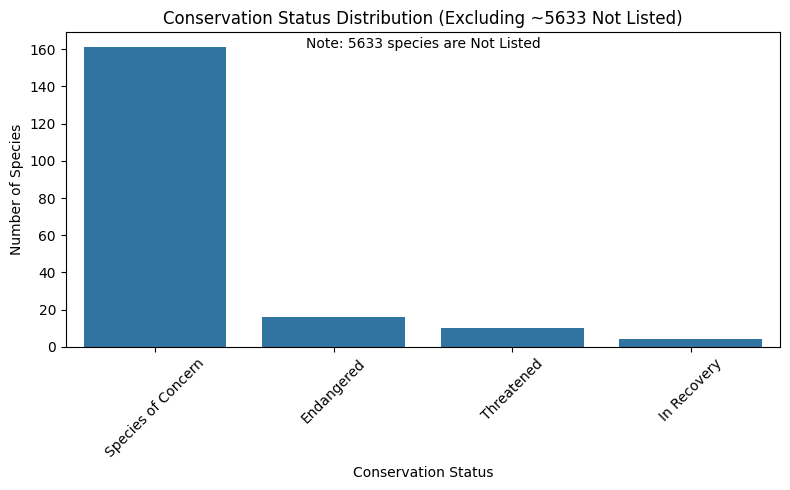

In [52]:
# Bar Plot: Conservation Status Counts (Excluding Not Listed)
plt.figure(figsize=(8, 5))
non_listed_data = species_info[species_info['conservation_status'] != 'Not Listed']
sns.countplot(data=non_listed_data, x='conservation_status', order=non_listed_data['conservation_status'].value_counts().index)
plt.title('Conservation Status Distribution (Excluding ~5633 Not Listed)')
plt.xlabel('Conservation Status')
plt.ylabel('Number of Species')
plt.xticks(rotation=45)
not_listed_count = species_info['conservation_status'].value_counts().get('Not Listed', 0)
plt.text(0.5, 0.95, f'Note: {not_listed_count} species are Not Listed', transform=plt.gca().transAxes, ha='center')
plt.tight_layout()
plt.savefig('conservation_status.png')
plt.show()

<Figure size 800x500 with 0 Axes>

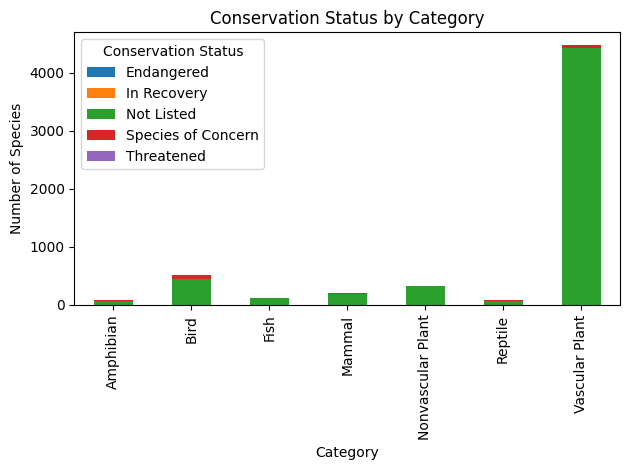

In [54]:
# Stacked Bar Plot: Conservation Status by Category
plt.figure(figsize=(8, 5))
status_by_category = pd.crosstab(species_info['category'], species_info['conservation_status'])
status_by_category.plot(kind='bar', stacked=True)
plt.title('Conservation Status by Category')
plt.xlabel('Category')
plt.ylabel('Number of Species')
plt.legend(title='Conservation Status')
plt.tight_layout()
plt.savefig('status_by_category.png')
plt.show()

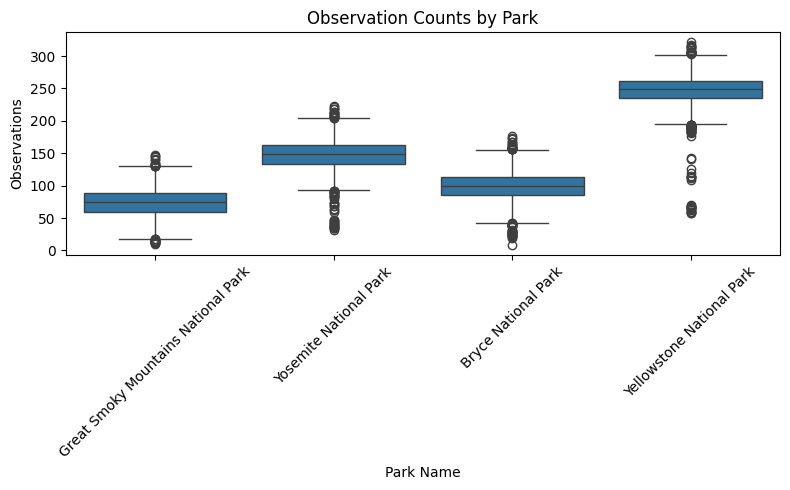

In [57]:
# Box Plot: Observations by Park
plt.figure(figsize=(8, 5))
sns.boxplot(data=observations, x='park_name', y='observations')
plt.title('Observation Counts by Park')
plt.xlabel('Park Name')
plt.ylabel('Observations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('observations_by_park.png')
plt.show()

In [58]:
print("Visualizations saved as PNGs: conservation_status.png, status_by_category.png, observations_by_park.png")

Visualizations saved as PNGs: conservation_status.png, status_by_category.png, observations_by_park.png


In [30]:
# Insights (to be documented in markdown)
print("\nInitial Insights:")
print("- Most species (~5633) are 'Not Listed', with ~191 in conservation statuses (e.g., Species of Concern, Endangered).")
print("- Vascular Plants dominate the dataset, followed by Birds and Mammals.")
print("- Mammals and Birds have higher proportions of Endangered/Threatened statuses.")
print("- Yellowstone has the highest total observations, indicating greater species activity or survey effort.")


Initial Insights:
- Most species (~5633) are 'Not Listed', with ~191 in conservation statuses (e.g., Species of Concern, Endangered).
- Vascular Plants dominate the dataset, followed by Birds and Mammals.
- Mammals and Birds have higher proportions of Endangered/Threatened statuses.
- Yellowstone has the highest total observations, indicating greater species activity or survey effort.


# Conclusions

## Analysis Process
This project analyzed endangered species data from the National Parks Service using two datasets: `species_info.csv` (species details and conservation statuses) and `observations.csv` (sightings over 7 days). The process involved:
- **Loading and Verification**: Loaded datasets, removed 15 duplicates in `observations`, imputed `"Not Listed"` for 5633 missing `conservation_status` values, and verified alignment (5541 common `scientific_name` values, 7 categories, 4 parks).
- **Exploration**: Calculated summary statistics (species by category/status, observations by park) and created visualizations (bar plots for conservation status, stacked bar plot by category, box plot for observations).
- **Visualization Focus**: Excluded 5633 `"Not Listed"` species from the conservation status bar plot to emphasize 191 species with conservation concerns (e.g., `Species of Concern`, `Endangered`).

## Key Findings
- **Conservation Status**: Of 5824 species, 5633 (96.7%) are `"Not Listed"`, indicating no conservation concern. The remaining 191 species are primarily `Species of Concern` (161), `Endangered` (16), and `Threatened` (10).
- **Category Patterns**: Vascular Plants dominate (4470 species), followed by Birds (521) and Mammals (214). Mammals and Birds have higher proportions of `Endangered` and `Threatened` statuses, suggesting greater conservation needs for vertebrates.
- **Observation Trends**: Yellowstone National Park has the highest total observations (1.4M), likely due to greater survey effort or species diversity. Average observations per species are similar across parks (100–150), with some outliers.
- **Visualization Insight**: The bar plot excluding `"Not Listed"` species clearly highlights conservation priorities, with `Species of Concern` being the most common non-`Not Listed` status.

## Implications and Next Steps
- **Conservation Priorities**: Focus on Mammals and Birds, which show higher endangerment rates, for targeted protection efforts.
- **Park-Specific Analysis**: Investigate Yellowstone’s high observation counts to understand if they reflect true species abundance or enhanced monitoring.
- **Further Analysis**: Examine whether endangered species have lower observation counts, indicating rarity, and analyze park-specific conservation status distributions.
- **Presentation**: These findings will be compiled into a slide deck (Step 6) to communicate results effectively to stakeholders.

This analysis provides a foundation for understanding endangered species patterns and informs conservation strategies across national parks.

# Communicating the findings

To communicate the findings effectively, a slide deck was created using LaTeX Beamer, presenting the analysis of endangered species in national parks. The slide deck includes:
- **Title Slide**: Project title, author, and date.
- **Project Overview**: Goals and datasets used.
- **Data Description**: Structure of `species_info.csv` and `observations.csv`, including cleaning steps.
- **Visualizations**: Bar plot of conservation statuses (excluding `Not Listed`), stacked bar plot by category, and box plot of observations by park.
- **Key Findings**: Insights on conservation status distribution, category patterns, and observation trends.
- **Conclusions**: Summary of findings and next steps for conservation.

The slide deck is saved as `biodiversity_presentation.pdf` and includes visualizations exported as PNGs (`conservation_status.png`, `status_by_category.png`, `observations_by_park.png`).